# 📊 Phần 2: Ứng Dụng Dữ Liệu Thực Tế - Dự Đoán Mức Lương NBA

Notebook này thực hiện toàn bộ quy trình từ Khảo sát dữ liệu (EDA), Tiền xử lý dữ liệu hướng đối tượng (OOP Data Pipeline), Huấn luyện & so sánh các mô hình hồi quy (OLS, OLS chọn biến, Ridge, Lasso, Bayesian Linear Regression) và trực quan hóa kết quả.

## 1. Khảo sát dữ liệu (Exploratory Data Analysis - EDA)

Chúng ta sẽ đọc dữ liệu từ file csv và khảo sát sơ bộ:
- Kích thước dữ liệu
- Tỷ lệ giá trị khuyết (Missing Values)
- Phân phối mức lương cầu thủ (Salary) và lý do sử dụng phép biến đổi Logarit $y' = \ln(\text{Salary})$

📊 Kích thước dữ liệu: (467, 52)

--- Tỷ lệ giá trị khuyết tự nhiên trong từng biến ---
FG%     0.002141
3P%     0.027837
2P%     0.008565
eFG%    0.002141
FT%     0.049251
TS%     0.002141
3PAr    0.002141
FTr     0.002141
dtype: float64


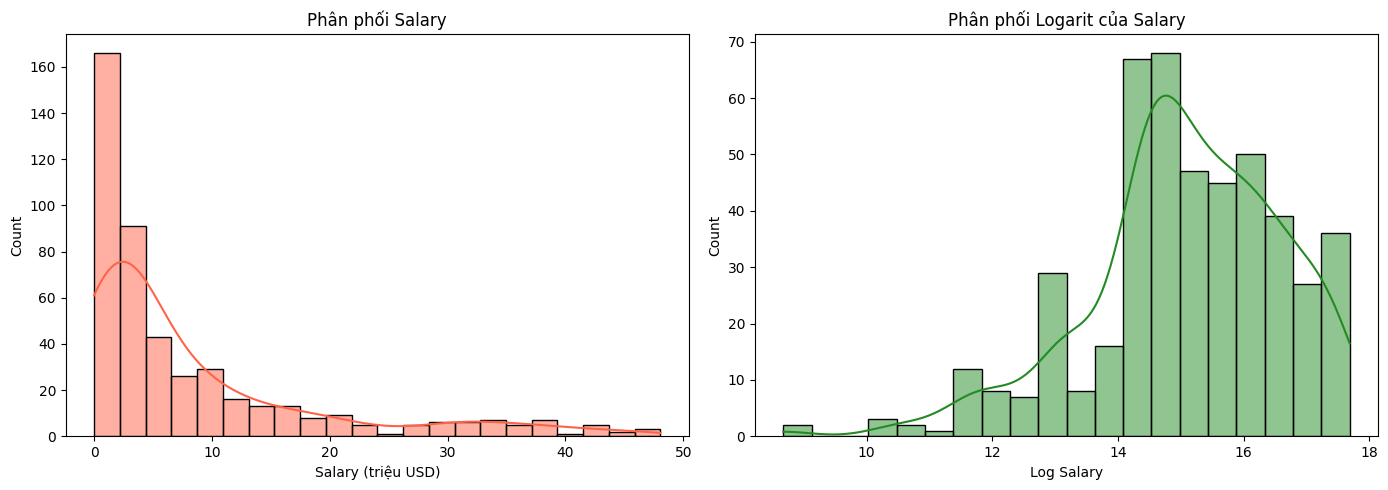

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd())))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = 'part2/data/nba_salary_raw.csv'
if not os.path.exists(data_path):
    data_path = 'part2/data/nba_salaries.csv'
df = pd.read_csv(data_path)

print("📊 Kích thước dữ liệu:", df.shape)
print("\n--- Tỷ lệ giá trị khuyết tự nhiên trong từng biến ---")
missing = df.isnull().mean()
print(missing[missing > 0])

# Trực quan phân phối mức lương
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Salary'] / 1e6, kde=True, ax=axes[0], color='tomato')
axes[0].set_xlabel('Salary (triệu USD)')
axes[0].set_title('Phân phối Salary')

sns.histplot(np.log(df['Salary']), kde=True, ax=axes[1], color='forestgreen')
axes[1].set_xlabel('Log Salary')
axes[1].set_title('Phân phối Logarit của Salary')
plt.tight_layout()
plt.show()

### 1.1. Thống kê mô tả (Descriptive Statistics)
Xem xét các đại lượng thống kê cơ bản: mean, median, std, min, max, quartiles.

In [2]:
print("--- Thống kê mô tả ---")
display(df.describe())



--- Thống kê mô tả ---


,Unnamed: 0,Salary,Age,GP,GS,MP,FG,FGA,FG%,3P,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
count,467.000000,4.670000e+02,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,466.000000,467.000000,...,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000
mean,233.000000,8.416599e+06,25.820128,48.233405,22.650964,19.871306,3.351392,7.117773,0.465009,0.996574,...,12.735974,18.425910,1.208351,1.120557,2.328908,0.081771,-1.344968,-0.087152,-1.432548,0.539829
std,134.955548,1.070812e+07,4.275113,24.807740,27.094577,9.548684,2.457836,5.020700,0.109547,0.880468,...,7.198533,5.909528,1.765160,0.980478,2.533094,0.088089,3.578193,2.243437,4.925175,1.172960
min,0.000000,5.849000e+03,19.000000,1.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000,5.100000,-1.900000,0.000000,-1.600000,-0.517000,-22.500000,-10.400000,-26.500000,-1.300000
25%,116.500000,1.782621e+06,23.000000,31.000000,1.000000,12.500000,1.600000,3.300000,0.417000,0.300000,...,9.500000,14.300000,0.000000,0.300000,0.300000,0.047000,-2.900000,-0.900000,-3.300000,-0.100000
50%,233.000000,3.722040e+06,25.000000,55.000000,8.000000,19.200000,2.700000,5.800000,0.455000,0.800000,...,11.900000,17.600000,0.600000,0.900000,1.500000,0.087000,-1.300000,-0.100000,-1.300000,0.100000
75%,349.500000,1.063354e+07,29.000000,68.500000,45.500000,28.300000,4.300000,9.400000,0.507500,1.500000,...,15.000000,21.150000,1.800000,1.800000,3.550000,0.129500,0.450000,0.800000,0.600000,0.800000
max,466.000000,4.807001e+07,42.000000,83.000000,83.000000,41.000000,11.200000,22.200000,1.000000,4.900000,...,100.000000,52.500000,9.600000,4.800000,12.600000,0.626000,17.000000,32.700000,48.600000,6.400000


### 1.2. Phân phối từng biến & Boxplot (Phát hiện Outliers)
Sử dụng Histogram để xem phân phối và Boxplot để kiểm tra các điểm dị biệt (Outliers) dựa trên khoảng phân vị (IQR).

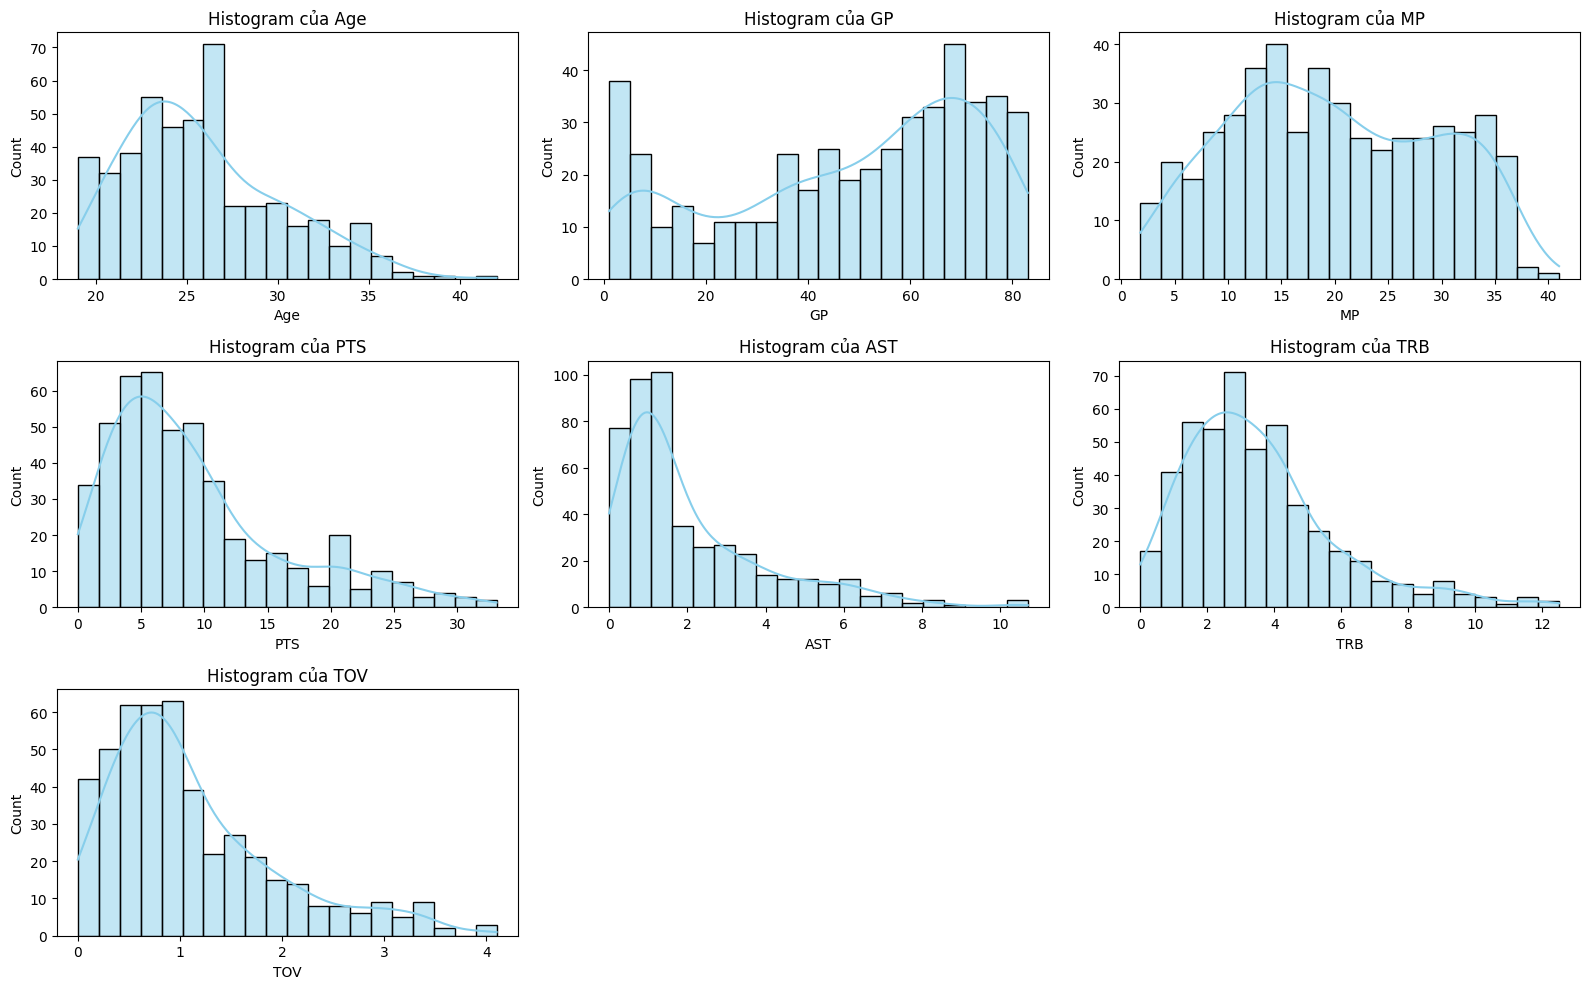

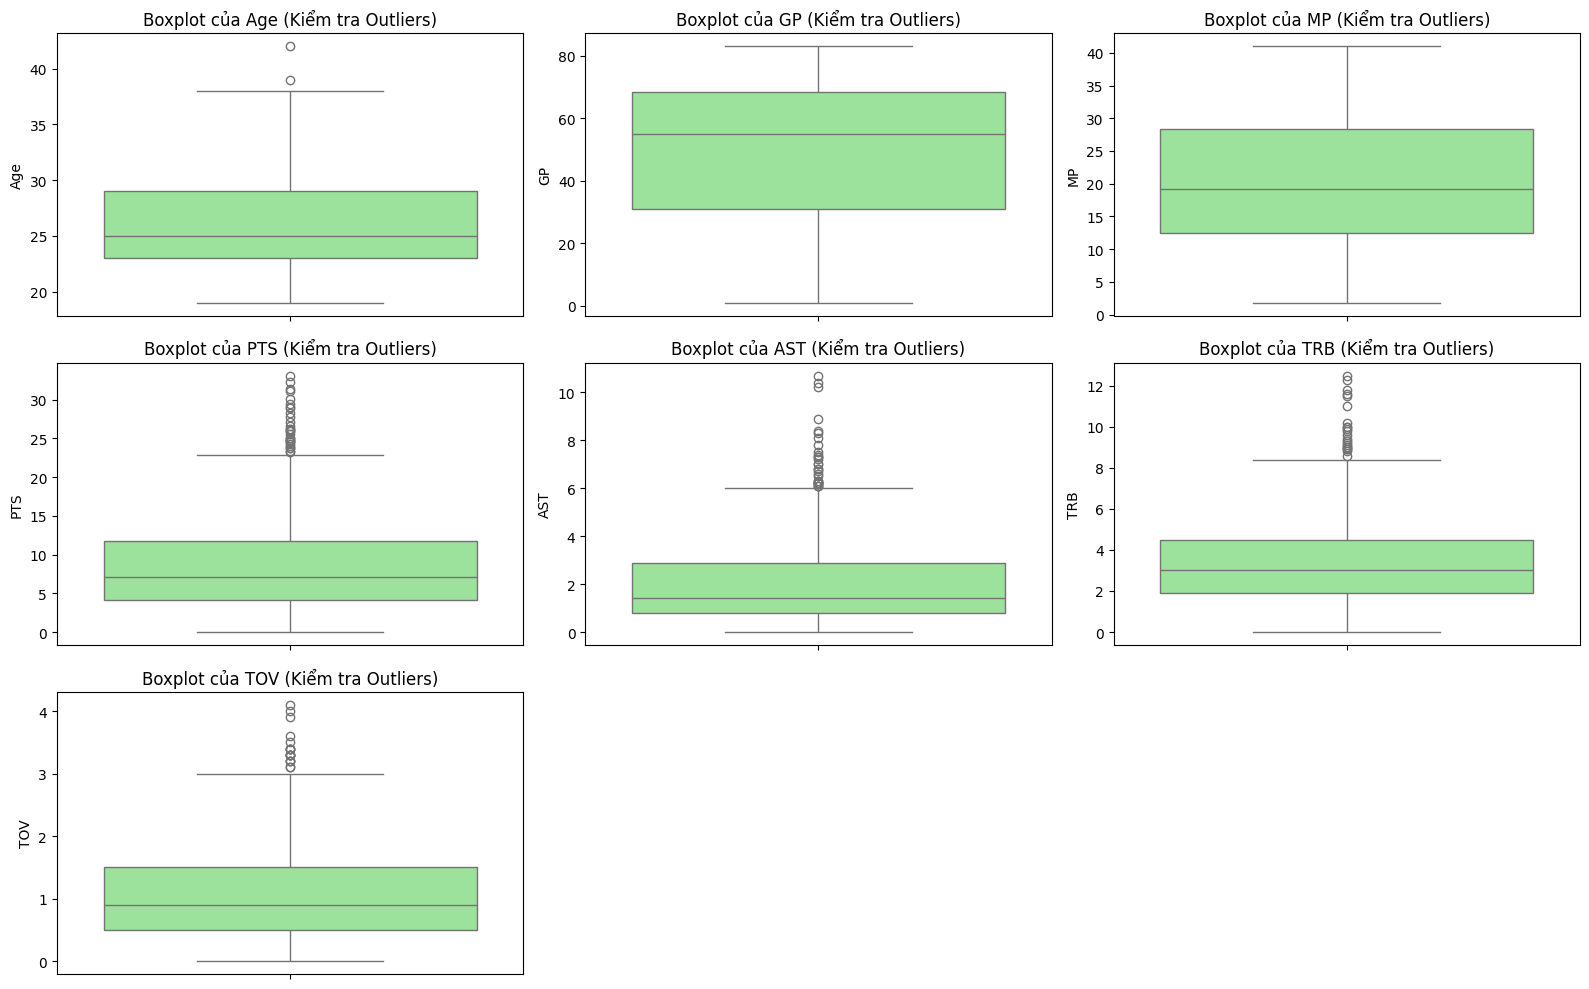

In [3]:
# Lấy các cột số (features thi đấu) để phân tích
numeric_cols = ['Age', 'GP', 'MP', 'PTS', 'AST', 'TRB', 'TOV']

# Vẽ Histogram
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Histogram của {col}')
plt.tight_layout()
plt.show()

# Vẽ Boxplot
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot của {col} (Kiểm tra Outliers)')
plt.tight_layout()
plt.show()

### 1.3. Ma trận tương quan (Correlation Heatmap)
Kiểm tra mức độ tương quan giữa các biến với nhau để xem biến nào ảnh hưởng mạnh đến Lương (Salary) và phát hiện đa cộng tuyến (Multicollinearity).

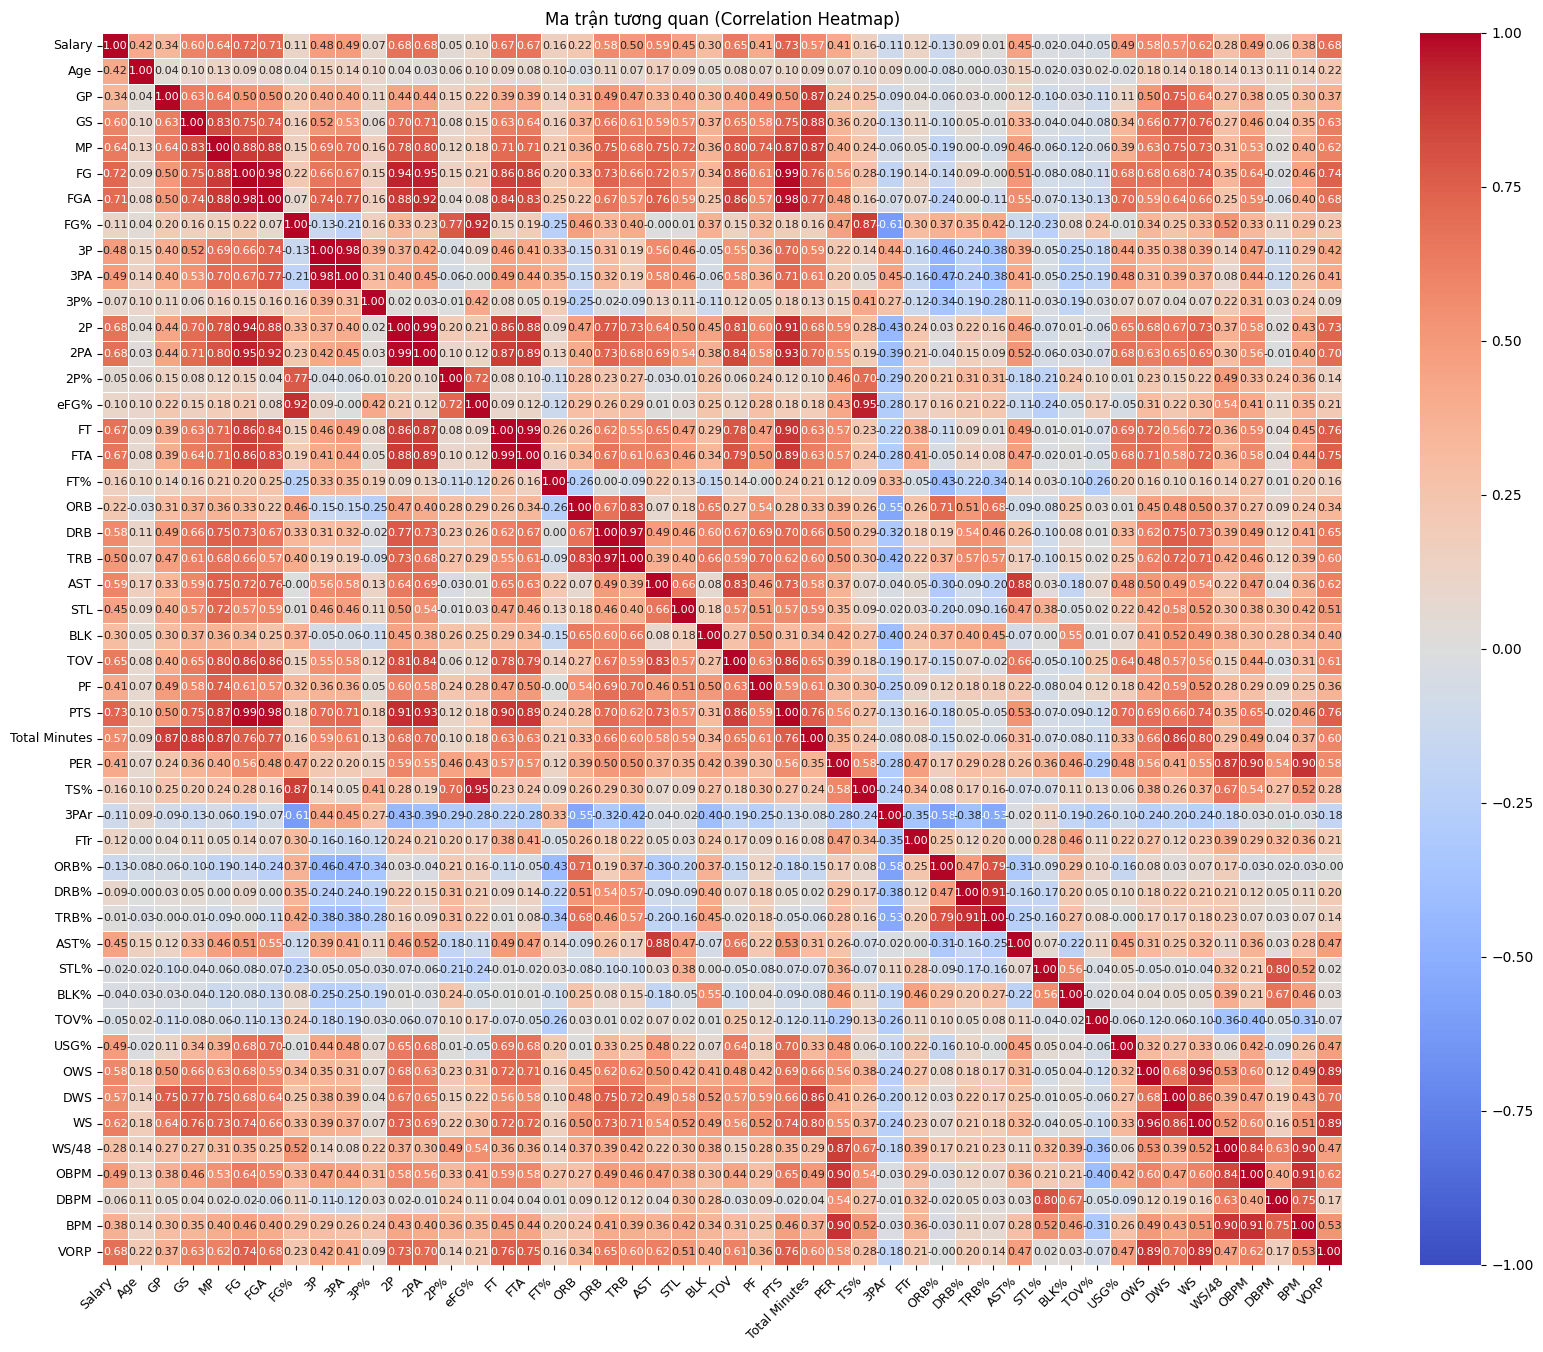

In [4]:
plt.figure(figsize=(20, 16))
# Tính ma trận tương quan (Pearson) cho các cột số
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, annot_kws={'size': 8}, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

## 2. Tiền xử lý dữ liệu (OOP Data Pipeline)

Chúng ta chạy class `NBADataPipeline` thiết kế từ `part2/data_pipeline.py`. Quy trình tiền xử lý tuân thủ:
1. Chia Train/Test riêng biệt trước để chống rò rỉ dữ liệu (Data Leakage).
2. Chuẩn hóa đặc trưng số (Standardization) dựa trên thông số từ tập Train.
3. Điền khuyết bằng thuật toán K-NN (KNN Imputer) trên thang đo chuẩn hóa để tính khoảng cách chính xác.
4. Encode biến phân loại (Dummy Variables) và căn chỉnh tập Test trùng khớp tập Train.

In [5]:
from part2.data_pipeline import NBADataPipeline

# Chia tập dữ liệu
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

# Thực thi quy trình
pipeline = NBADataPipeline()
X_train, y_train, X_test, y_test = pipeline.process_pipeline(train_df, test_df)

print(f"Kích thước dữ liệu huấn luyện X_Train: {X_train.shape} | Y_Train: {y_train.shape}")
print(f"Kích thước dữ liệu kiểm thử    X_Test:  {X_test.shape}  | Y_Test:  {y_test.shape}")
print(f"Còn NaN trong tập huấn luyện? ->", X_train.isnull().sum().sum() > 0)

Kích thước dữ liệu huấn luyện X_Train: (374, 81) | Y_Train: (374,)
Kích thước dữ liệu kiểm thử    X_Test:  (93, 81)  | Y_Test:  (93,)
Còn NaN trong tập huấn luyện? -> False


### Khảo sát lại ma trận tương quan sau khi qua Pipeline
Chúng ta hãy vẽ lại Heatmap để kiểm chứng:

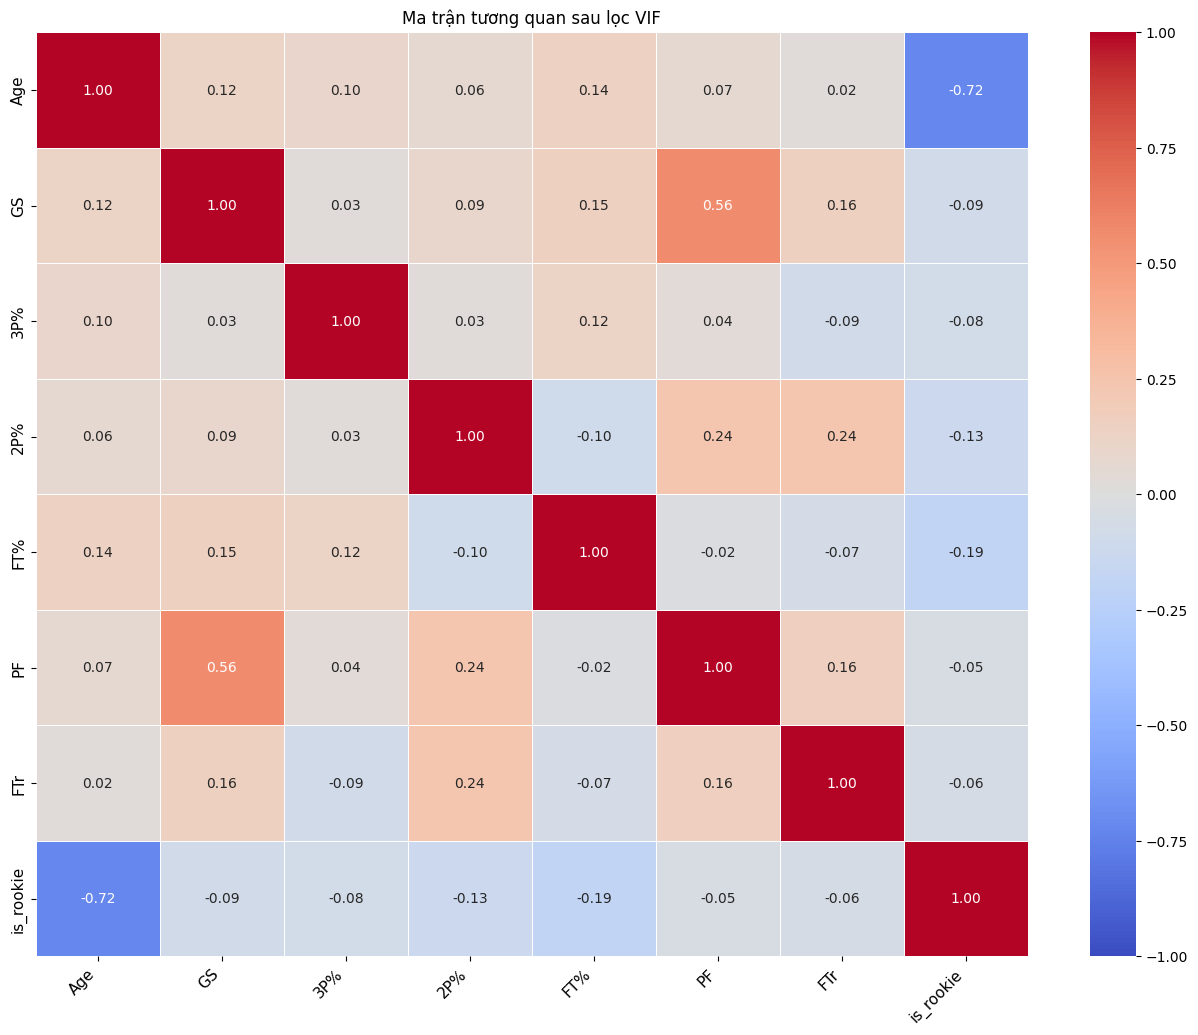

In [6]:
# Lọc ra các cột số (không tính cột phân loại - Dummy) trong X_train để vẽ
numeric_cols_after = pipeline.vif_passed_features
corr_matrix_after = X_train[numeric_cols_after].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_after, annot=True, annot_kws={'size': 10}, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.title(f'Ma trận tương quan sau lọc VIF')
plt.show()

## 3. Huấn luyện và So sánh các mô hình

Chúng ta sẽ thực thi toàn bộ script `part2/model_comparison.py` để:
- Huấn luyện 5 mô hình (OLS, OLS chọn biến, Ridge, Lasso, Bayesian)
- Đánh giá mô hình trên tập Test riêng biệt thông qua các chỉ số MAE, RMSE, R2 trên thang đo gốc (USD)
- Vẽ đồ thị phân tích chẩn đoán phần dư
- Vẽ đồ thị khoảng tin cậy Bayesian

In [7]:
from part2.model_comparison import main
main()

CHƯƠNG TRÌNH SO SÁNH CÁC MÔ HÌNH HỒI QUY TRÊN DỮ LIỆU NBA
1. Đang tải bộ dữ liệu từ: d:\TUDTK\TUDTK_DA2\part2\data\nba_salary_raw.csv
2. Chia dữ liệu thành tập Train (80%) và Test (20%) với seed 42
3. Tiền xử lý dữ liệu qua NBADataPipeline...

Huấn luyện Model 1: OLS Cơ Bản...
Huấn luyện Model 2: OLS Chọn Biến...
  - VIF lọc giảm số lượng đặc trưng từ 81 xuống 81
  - p-value lọc giảm tiếp số lượng đặc trưng xuống 3: ['Age', 'GS', 'PF']
Huấn luyện Model 3: Ridge Regression...
✅ Đã lưu Ridge Trace tại: ridge_trace.png
  - Ridge: Lambda tối ưu chọn bởi 5-Fold CV: 10.0
Huấn luyện Model 4: Lasso Regression...
  - Lasso: Lambda tối ưu chọn bởi 5-Fold CV: 1.0
Huấn luyện Model 5: Bayesian Linear Regression...

KẾT QUẢ SO SÁNH CÁC MÔ HÌNH (ĐÁNH GIÁ TRÊN TẬP TEST - ĐƠN VỊ USD)
            Mô hình    MAE (USD)    RMSE (USD) R2 Score Ghi chú/Siêu tham số
         OLS Cơ Bản 6,086,465.77 13,875,766.77  -1.0392             Mặc định
      OLS Chọn Biến 4,404,517.21  8,311,748.61   0.2683          3 đ

## 4. Hiển thị trực tiếp các kết quả trực quan hóa

Dưới đây là các hình ảnh biểu đồ phân tích và kết quả dự đoán được sinh ra từ quy trình so sánh mô hình:

1. Phân Tích Chẩn Đoán Phần Dư (Mô hình tốt nhất)


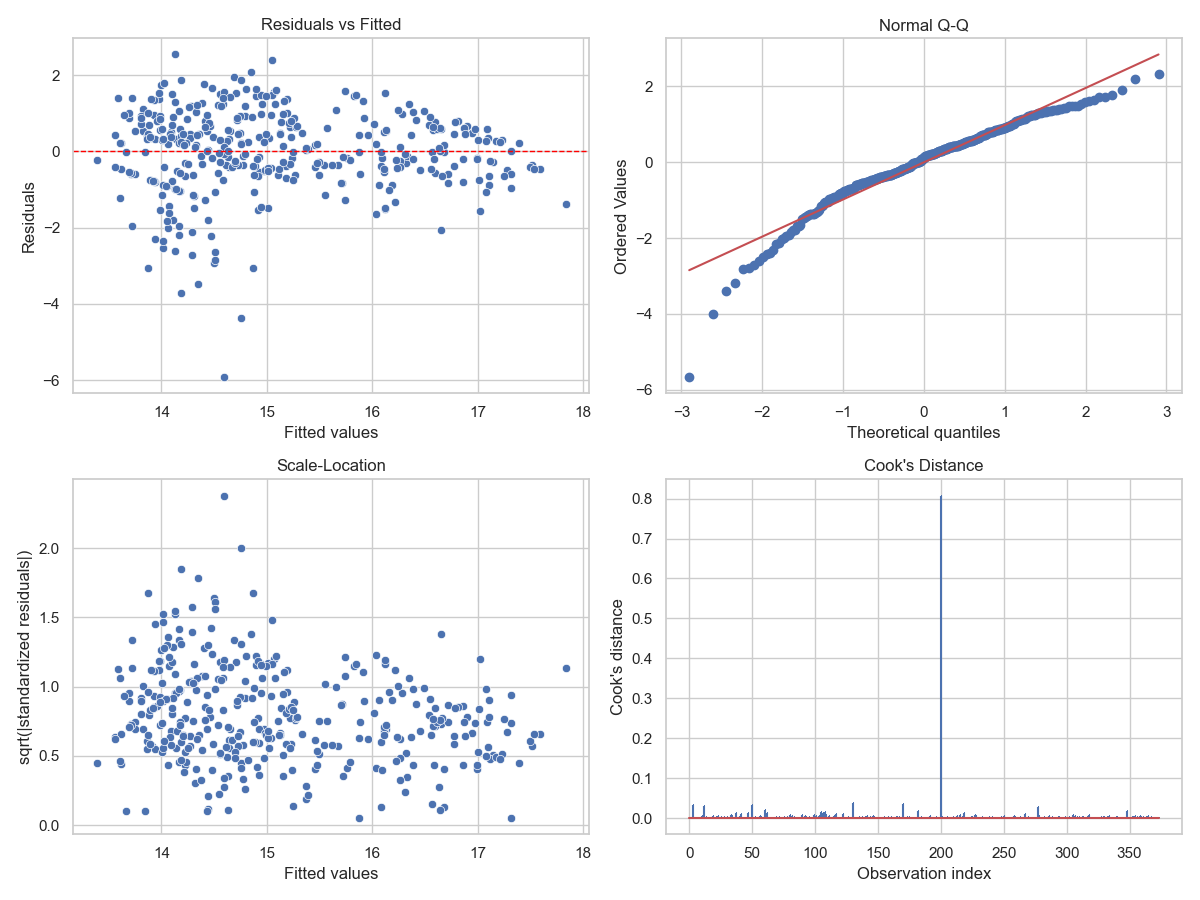


2. Ridge Trace Analysis


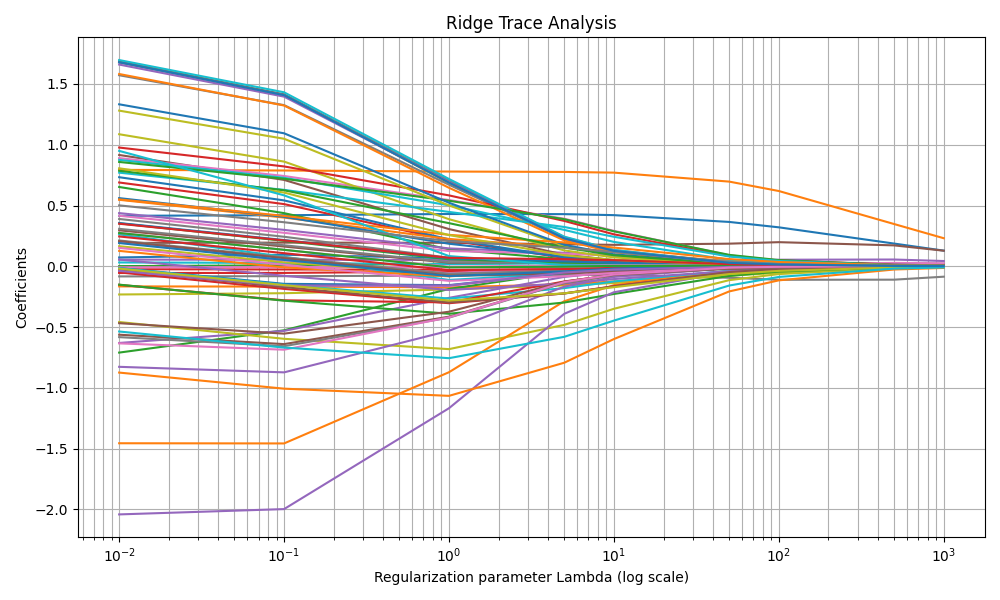


3. Khoảng Dự Đoán Tin Cậy Bayesian 95%


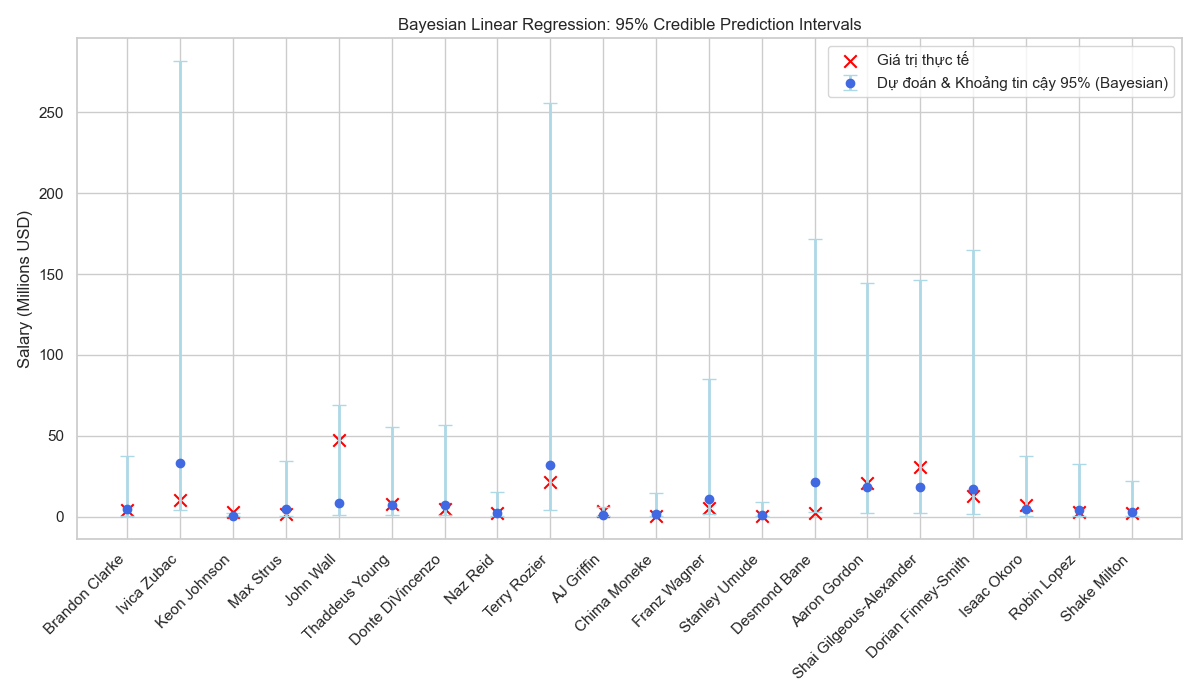

In [8]:
from IPython.display import Image, display
import os

# 1. Đồ thị chẩn đoán phần dư của mô hình tốt nhất
if os.path.exists('residuals_diagnostic.png'):
    print("1. Phân Tích Chẩn Đoán Phần Dư (Mô hình tốt nhất)")
    display(Image('residuals_diagnostic.png'))

# 2. Ridge Trace
if os.path.exists('ridge_trace.png'):
    print("\n2. Ridge Trace Analysis")
    display(Image('ridge_trace.png'))

# 3. Bayesian Prediction Intervals
if os.path.exists('bayesian_prediction_intervals.png'):
    print("\n3. Khoảng Dự Đoán Tin Cậy Bayesian 95%")
    display(Image('bayesian_prediction_intervals.png'))